# Getting started

A placeholder that exercises the docs pipeline: Markdown, code, text output, and a figure. Real examples arrive with the query API.

Errors carry the status code, the number of attempts, and the URL:

In [1]:
from water_ogcapi.exceptions import ServiceError

url = "https://api.waterdata.usgs.gov/ogcapi/v0/collections"
print(ServiceError("service unavailable", url, status=503, attempts=4))

HTTP 503: service unavailable (after 4 attempts)
URL: https://api.waterdata.usgs.gov/ogcapi/v0/collections


The transport waits 0.5 s before its first retry, doubles the wait each time, and caps it at 60 s. The default allows three retries; the figure shows eight.

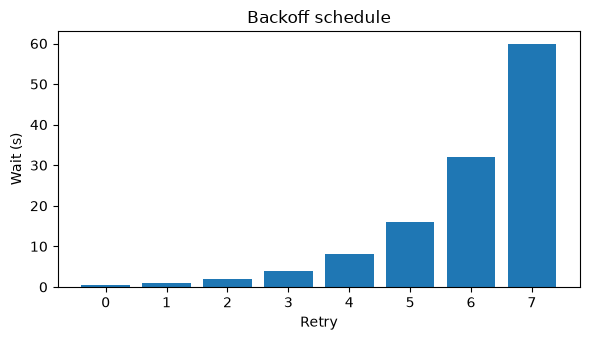

In [2]:
import matplotlib.pyplot as plt

attempts = range(8)
delays = [min(0.5 * 2**n, 60.0) for n in attempts]

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(attempts, delays)
ax.set(xlabel="Retry", ylabel="Wait (s)", title="Backoff schedule")
fig.tight_layout()